# Check out Parameter Calibration

In [25]:
import os
import numpy as np
import xarray as xr
import pandas as pd

import fates_calibration_library.utils as utils
import fates_calibration_library.emulator_functions as em
import fates_calibration_library.parameter_generation as param
import fates_calibration_library.calibration as cal
import fates_calibration_library.plotting_functions as plotting

import seaborn as sns
import matplotlib.pyplot as plt
import importlib

## Set Up
Load files, set up ensemble information

In [4]:
top_dir = '/glade/work/afoster/FATES_calibration'
param_dir = os.path.join(top_dir, 'parameter_files')
emulator_dir = os.path.join(top_dir, 'emulators')
mesh_dir = os.path.join(top_dir, 'mesh_files')
fig_dir = os.path.join(top_dir, 'figures')
out_dir = os.path.join(top_dir, 'param_outputs_history_matching')

calib_var_file = os.path.join(top_dir, 'emulator_configs', 'calibration_vars.yaml')
pft_id_config = os.path.join(top_dir, 'fates_calibration_library/configs/fates_pft_ids.yaml')
obs_config_file = os.path.join(top_dir, 'fates_calibration_library/configs/ilamb_conversion.yaml')

param_file_name = 'fates_params_default_sci.1.85.1_api.40.0.0_crops.nc'
param_list_name = "param_list_sci.1.85.1_api.40.0.0.xls"
default_param = xr.open_dataset(os.path.join(param_dir, param_file_name))
param_list_file = os.path.join(param_dir, param_list_name)
param_dat = param.get_param_dictionary(param_list_file)

In [5]:
calib_vars_config = utils.get_config_file(calib_var_file)
pft_ids = utils.get_config_file(pft_id_config)
obs_config = utils.get_config_file(obs_config_file)

In [6]:
# PFT names
all_pfts = [str(pft).replace("b'", "").replace("'", "").strip() for pft in default_param.fates_pftname.values]

# normalized values for parameters
default_norm = pd.read_csv(os.path.join(param_dir, 'normalized_parameters.csv'), index_col=[0])

In [7]:
# information about each ensemble
ens_dict = {'dompft':
            {'mesh_file': os.path.join(mesh_dir, 'dominant_grid_mesh.nc'),
             'land_mask_file': os.path.join(mesh_dir, 'dominant_grid.nc'),
             'lhc_key_file': os.path.join(param_dir, 'fates_lh', 'fates_lh_key.csv'),
             'pfts': [1, 2, 3, 12, 13],
             'obs_df': os.path.join(mesh_dir, 'dominant_grid.csv'),
            },
            'codompft':
            {'mesh_file': os.path.join(mesh_dir, 'co-dominant_grid_mesh.nc'),
             'land_mask_file': os.path.join(mesh_dir, 'co-dominant_grid.nc'),
             'lhc_key_file': os.path.join(param_dir, 'fates_lh_codom', 'fates_lh_key.csv'),
             'pfts': [4, 6, 11, 14],
             'obs_df': os.path.join(mesh_dir, 'co-dominant_grid.csv'),
            }
           }

In [9]:
# choose ensemble
ensemble = 'codompft'

## Ensemble Investigation

### Load data
Load Latin Hypercube key and observations

In [10]:
# load latin hypercube key
lhc_key = pd.read_csv(ens_dict[ensemble]['lhc_key_file'], index_col=[0])
lhc_key = lhc_key.drop(columns=['ensemble'])
param_names = lhc_key.columns
num_params = len(param_names)

# load observations
obs = pd.read_csv(ens_dict[ensemble]['obs_df'], index_col=[0])

### PFT Investigation

In [11]:
# choose pft
pft = 14
pft_name = all_pfts[pft-1]
pft_id = pft_ids[pft_name]
calibration_vars = calib_vars_config[pft_id] 

In [12]:
print(f"{pft_name}: {calibration_vars}")

c4_grass: ['GPP', 'EFLX_LH_TOT', 'EF']


Load emulators and subset observations

In [17]:
# get observations for this pft
obs_pft = obs[obs.pft == pft_name]

if pft_id != 'BEET':
    obs_pft = obs_pft[obs_pft.land_frac > 0.99]
if pft_id != 'AC3G':
    obs_pft = obs_pft[obs_pft.pct_lake < 30]

# get default values for this pft
X_default_all = cal.get_default_pft_values(default_norm, pft)

# load emulators, targets, and sds
emulators, targets, sds = cal.prep_calibration_data(obs_pft, calibration_vars,
                                                   obs_config, emulator_dir,
                                                   pft_name, pft_id)

2026-01-27 09:10:44.037166: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:266] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


### Calibrated parameter ensemble

In [31]:
importlib.reload(plotting)

<module 'fates_calibration_library.plotting_functions' from '/glade/work/afoster/FATES_calibration/fates_calibration_library/fates_calibration_library/plotting_functions.py'>

In [23]:
# get calibrated parameter distribution
calib_df = cal.get_calibrated_distribution(os.path.join(out_dir, f"{pft}_outputs"))

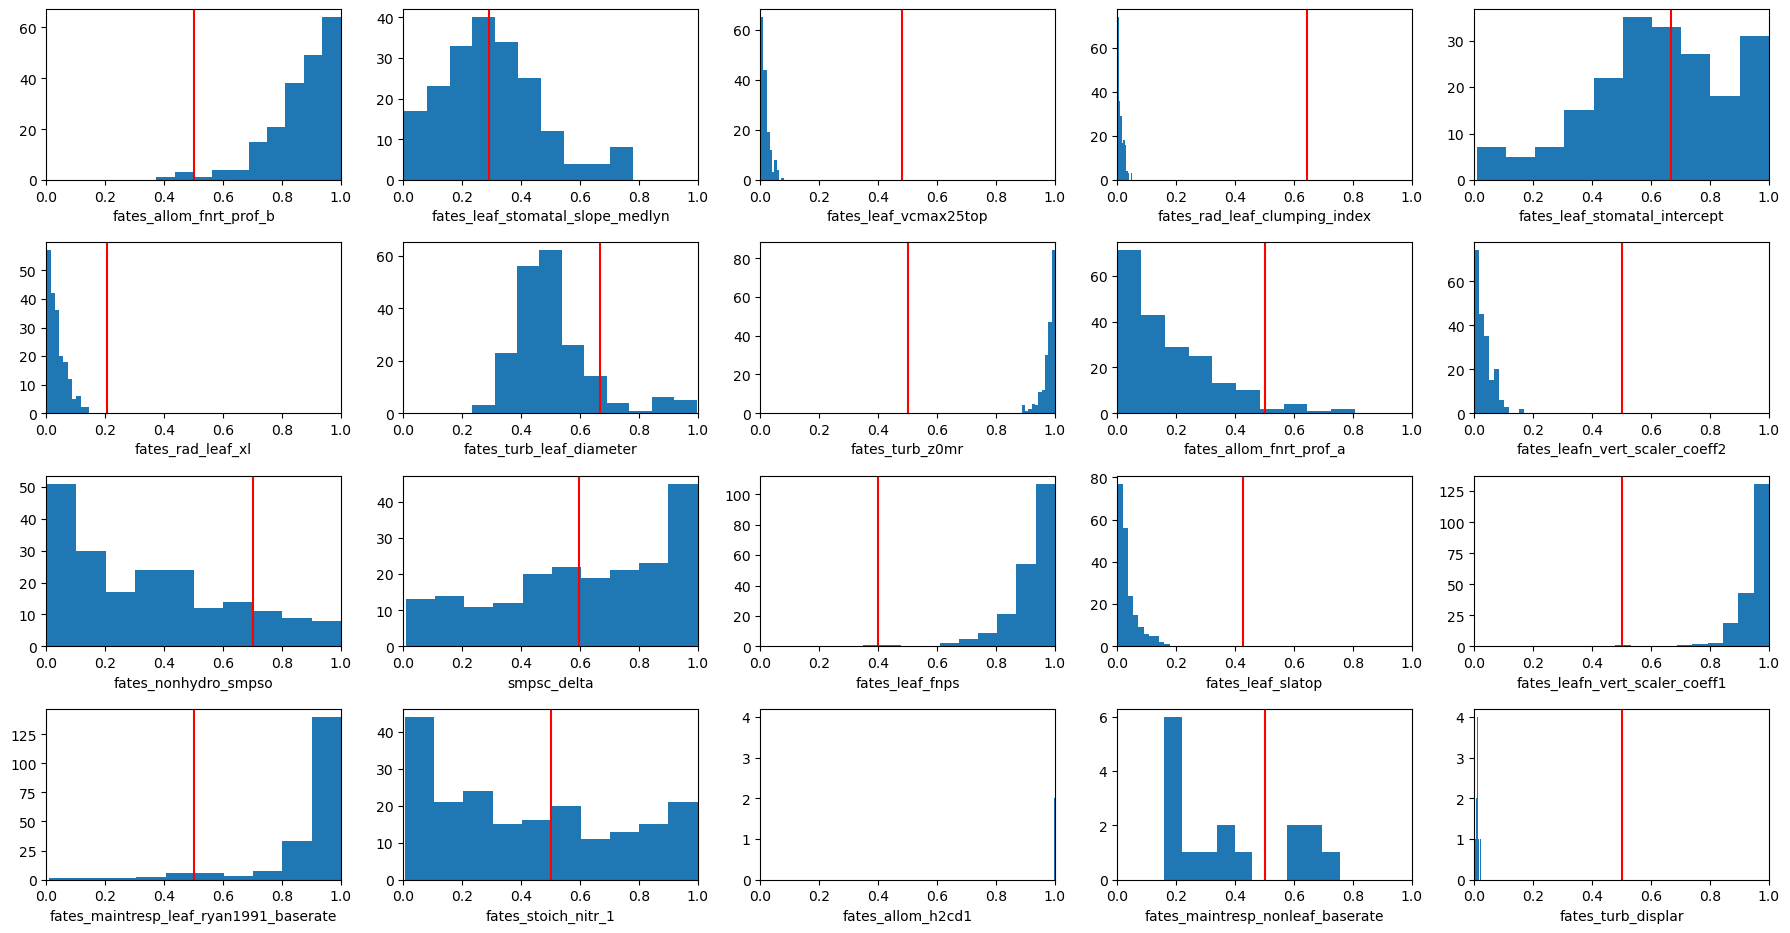

In [32]:
plotting.plot_parameter_hists(calib_df, default_norm[default_norm.pft == pft])

### Posterior summary statistics

#### Marginal mean, median, mode

In [ ]:
marginal_mean = df_subset.mean(axis=0)
marginal_median = df_subset.median(axis=0)

marginal_modes = {}
for parameter in df_subset.columns:
    marginal_modes[parameter] = marginal_mode_kde(df_subset[parameter].values)

summary_stats = pd.DataFrame({'parameter': marginal_mean.index,
                              'marginal_mean': marginal_mean.values,
                              'marginal_median': marginal_median.values,
                              'marginal_mode': marginal_modes.values()}).melt(id_vars=['parameter'])

In [ ]:
plt.figure(figsize=(5,7))
sns.barplot(data=summary_stats, y='parameter',
            x='value', hue='variable')
plt.legend(bbox_to_anchor=(1.0, 1.0));

### Correlations

In [ ]:
parameter_corr = get_corr(df_subset)
plt.figure(figsize=(12, 8))
sns.heatmap(parameter_corr, annot=True, cmap='coolwarm', center=0)

In [ ]:
pars_to_choose = ['fates_leaf_vcmax25top',
                  'fates_leaf_slatop',
                  'fates_leaf_stomatal_intercept',
                  'fates_leaf_stomatal_slope_medlyn']

In [ ]:
final_pars = get_final_params(pars_to_choose[0], df_subset).to_frame().T
plot_parameter_hists(df_subset, default_norm[default_norm.pft == pft],
                     final_pars)

In [ ]:
rescaled_values = get_rescaled(df_subset.columns, final_pars)
df = pd.DataFrame({'parameter_value': rescaled_values})
df['parameter_name'] = df.index
df['PFT'] = pft_id
df = df.reset_index()
df.to_csv(os.path.join(out_dir, f"{pft_id}_final_param_choice.csv"))

In [ ]:
df_subset.columns

In [ ]:
pfts = [1, 2, 3, 12, 13]
pft_names = [all_pfts[pft-1] for pft in pfts]
pft_codes = [pft_ids[pft_name] for pft_name in pft_names]

In [ ]:
all_dfs = []
for pft in pfts:
    pft_name = all_pfts[pft-1]
    pft_code = pft_ids[pft_name]
    df = pd.read_csv(os.path.join(out_dir, f"{pft_code}_final_param_choice.csv"))
    df = df[['parameter_value', 'parameter_name', 'PFT']]
    df['pft_id'] = pft
    all_dfs.append(df)
df = pd.concat(all_dfs)

In [ ]:
df.to_csv(os.path.join(out_dir, 'all_dom_pfts_update.csv'))

In [ ]:
out_dir